# Nigeria Sentinel-1 Road Condition Experiments

This notebook tests whether Sentinel-1 GRD backscatter adds useful signal for road condition modelling against the NIRTIMS Nigeria labels. The experiment is deliberately framed as an ablation study:

| Feature set | Purpose |
|---|---|
| S1 only | Tests whether SAR backscatter alone contains road-condition signal. |
| S2 only | Keeps the optical satellite baseline used elsewhere in the dissertation. |
| S2 + S1 | Tests whether SAR adds incremental value beyond Sentinel-2. |
| Survey only | Measures how much signal comes from NIRTIMS engineering survey attributes. |
| Satellite + Survey | Tests whether satellite features complement field survey features. |
| Paved only | Removes the strongest pavement-material confound and asks whether condition can still be separated within paved roads. |

Research framing: current SAR road-condition studies commonly exploit backscatter intensity, temporal stability, polarisation contrasts, coherence, acquisition geometry and, where available, traffic or vehicle effects. The current export contains Sentinel-1 GRD VV/VH intensity summaries from a fixed ascending pass, so this notebook uses the defensible subset available from the data: VV, VH, VV-VH, their road-level dispersion, and temporal variability. Coherence and incident-angle correction are noted as next-stage improvements because they require additional exports or SLC processing not present in the current CSV/parquet data.

In [1]:
from pathlib import Path
import re
import warnings

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)


def find_repo_root(start=None, repo_name="Sentinel-FYP"):
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == repo_name:
            return candidate
    raise FileNotFoundError(f"Could not find repository root named {repo_name!r}")


def norm_code(series):
    return (
        series.astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.upper()
    )


def dominant(series):
    series = series.dropna()
    if series.empty:
        return np.nan
    return series.value_counts().idxmax()


ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
NIRTIMS = DATA_DIR / "nirtims_2025_11_14"
S2_PARQUET = DATA_DIR / "nigeria_parquet"
S1_PARQUET = DATA_DIR / "nigeria_s1_parquet"

# Keep this dynamic: by default, use every year present in both S1 and S2 parquet folders.
# To test only the survey-aligned year, set MODEL_YEARS = [2025].
available_s2_years = sorted(int(p.name.split("=")[1]) for p in S2_PARQUET.glob("year=*") if p.is_dir())
available_s1_years = sorted(int(p.name.split("=")[1]) for p in S1_PARQUET.glob("year=*") if p.is_dir())
MODEL_YEARS = sorted(set(available_s1_years).intersection(available_s2_years))

RANDOM_STATE = 42
TARGET_3_ORDER = ["good", "fair", "poor"]
TARGET_BINARY_ORDER = ["good", "poor"]

print(f"Repo root: {ROOT}")
print(f"S1 years: {available_s1_years}")
print(f"S2 years: {available_s2_years}")
print(f"Model years: {MODEL_YEARS}")

Repo root: /Users/miranda/Documents/GitHub/Sentinel-FYP
S1 years: [2020, 2021, 2022, 2023, 2024, 2025]
S2 years: [2020, 2021, 2022, 2023, 2024, 2025]
Model years: [2020, 2021, 2022, 2023, 2024, 2025]


## 1. Load NIRTIMS Labels and Survey Features

The target labels come from `RoadCondition.shp` (`SURFACECON`). As in the main Nigeria model, labels are collapsed from five survey classes to three dissertation classes: `Excellent/Good -> good`, `Fair -> fair`, and `Poor/Very Poor -> poor`. A second binary target is also produced where `Fair` is grouped with `Poor`, matching the planned good-vs-poor condition experiment.

In [2]:
road_cond = gpd.read_file(NIRTIMS / "RoadCondition.shp")
road_pave = gpd.read_file(NIRTIMS / "RoadPavement.shp")
prob_areas = gpd.read_file(NIRTIMS / "ProblemAreas.shp")
culverts = gpd.read_file(NIRTIMS / "Culverts.shp")
drains = gpd.read_file(NIRTIMS / "RoadSideDrains.shp")

for gdf in [road_cond, road_pave, prob_areas, culverts, drains]:
    gdf["ROADCODE_N"] = norm_code(gdf["ROADCODE"])

COND_ORDER = ["Excellent", "Good", "Fair", "Poor", "Very Poor"]
TARGET_3_MAP = {
    "Excellent": "good",
    "Good": "good",
    "Fair": "fair",
    "Poor": "poor",
    "Very Poor": "poor",
}
TARGET_BINARY_MAP = {
    "Excellent": "good",
    "Good": "good",
    "Fair": "poor",
    "Poor": "poor",
    "Very Poor": "poor",
}

road_cond["SURFACECON"] = road_cond["SURFACECON"].astype(str).str.strip()
cond_valid = road_cond[road_cond["SURFACECON"].isin(COND_ORDER)].copy()
cond_per_road = (
    cond_valid.groupby("ROADCODE_N")["SURFACECON"]
    .agg(dominant)
    .reset_index()
    .rename(columns={"SURFACECON": "surfacecon"})
)
cond_per_road["target_3"] = cond_per_road["surfacecon"].map(TARGET_3_MAP)
cond_per_road["target_binary"] = cond_per_road["surfacecon"].map(TARGET_BINARY_MAP)

# Pavement material: dominant surveyed material per road.
road_pave["PAVETYPE"] = road_pave["PAVETYPE"].astype(str).str.strip().str.upper()
pave_map = {
    "EARTHEN": "Earthen",
    "GRAVEL": "Gravel",
    "ASPHALT CONCRETE": "Asphalt",
    "DBST": "SurfaceDressing",
    "SBST": "SurfaceDressing",
    "CONCRETE": "Concrete",
}
road_pave["pave_type"] = road_pave["PAVETYPE"].map(pave_map).fillna("Other")
pave_per_road = (
    road_pave.groupby("ROADCODE_N")["pave_type"]
    .agg(dominant)
    .reset_index()
)

# Problem areas: defect counts and lengths by road.
prob_areas["PATYPE"] = prob_areas["PATYPE"].astype(str).str.strip()
prob_areas["PALENGTH"] = pd.to_numeric(prob_areas["PALENGTH"], errors="coerce")
pa_valid = prob_areas[prob_areas["PATYPE"].isin(["Erosion", "Waterlogging", "Landslide"])].copy()
pa_per_road = (
    pa_valid.groupby("ROADCODE_N")
    .agg(
        pa_count=("PATYPE", "count"),
        pa_total_len_m=("PALENGTH", "sum"),
        pa_mean_len_m=("PALENGTH", "mean"),
        pa_erosion_count=("PATYPE", lambda s: (s == "Erosion").sum()),
        pa_waterlog_count=("PATYPE", lambda s: (s == "Waterlogging").sum()),
        pa_landslide_count=("PATYPE", lambda s: (s == "Landslide").sum()),
    )
    .reset_index()
)
PA_FEAT_COLS = [
    "pa_count",
    "pa_total_len_m",
    "pa_mean_len_m",
    "pa_erosion_count",
    "pa_waterlog_count",
    "pa_landslide_count",
]

# Culverts: condition proxy from NIRTIMS survey.
CULVERT_SCORE = {"Good": 4, "Fair": 3, "Poor": 2, "Very Poor": 1, "Bad": 0}
culverts["CULVERTCON"] = culverts["CULVERTCON"].astype(str).str.strip()
culverts["culv_score"] = culverts["CULVERTCON"].map(CULVERT_SCORE)
culverts["culv_poor"] = culverts["CULVERTCON"].isin(["Poor", "Very Poor", "Bad"]).astype(int)
culv_per_road = (
    culverts.groupby("ROADCODE_N")
    .agg(
        culvert_count=("culv_score", "count"),
        culvert_mean_cond=("culv_score", "mean"),
        culvert_poor_count=("culv_poor", "sum"),
    )
    .reset_index()
)
culv_per_road["culvert_poor_ratio"] = (
    culv_per_road["culvert_poor_count"] / culv_per_road["culvert_count"]
)
CULV_FEAT_COLS = [
    "culvert_count",
    "culvert_mean_cond",
    "culvert_poor_count",
    "culvert_poor_ratio",
]

# Road-side drains: coverage/type proxy.
drains["DRAINTYPE"] = drains["DRAINTYPE"].astype(str).str.strip()
drains["FROMCH"] = pd.to_numeric(drains["FROMCH"], errors="coerce")
drains["TOCH"] = pd.to_numeric(drains["TOCH"], errors="coerce")
drains["drain_len_km"] = (drains["TOCH"] - drains["FROMCH"]).clip(lower=0)
drains["is_no_drain"] = (drains["DRAINTYPE"] == "No Drain").astype(int)
drains["is_concrete"] = drains["DRAINTYPE"].str.lower().str.contains("concrete").fillna(False).astype(int)
drain_per_road = (
    drains.groupby("ROADCODE_N")
    .agg(
        drain_segment_count=("drain_len_km", "count"),
        drain_total_len_km=("drain_len_km", "sum"),
        drain_no_drain_ratio=("is_no_drain", "mean"),
        drain_concrete_ratio=("is_concrete", "mean"),
    )
    .reset_index()
)
DRAIN_FEAT_COLS = [
    "drain_segment_count",
    "drain_total_len_km",
    "drain_no_drain_ratio",
    "drain_concrete_ratio",
]

print(f"Roads with dominant condition labels: {len(cond_per_road):,}")
print(cond_per_road["surfacecon"].value_counts().reindex(COND_ORDER).fillna(0).astype(int))
print("\n3-class target:")
print(cond_per_road["target_3"].value_counts().reindex(TARGET_3_ORDER).fillna(0).astype(int))
print("\nBinary target:")
print(cond_per_road["target_binary"].value_counts().reindex(TARGET_BINARY_ORDER).fillna(0).astype(int))

Roads with dominant condition labels: 4,573
surfacecon
Excellent     138
Good          598
Fair         1486
Poor         1766
Very Poor     585
Name: count, dtype: int64

3-class target:
target_3
good     736
fair    1486
poor    2351
Name: count, dtype: int64

Binary target:
target_binary
good     736
poor    3837
Name: count, dtype: int64


## 2. Load and Aggregate Sentinel-1 and Sentinel-2

Both sensors are reduced to one feature vector per road. For each spectral/SAR variable, the notebook calculates road-level mean, standard deviation, minimum, maximum, range, and a simple annual trend. This keeps the experiment dynamic: if the parquet data or model years change, the feature table updates automatically.

In [3]:
def read_year_partitions(root, years):
    frames = []
    for year in years:
        year_dir = root / f"year={year}"
        files = sorted(year_dir.glob("*.parquet"))
        if not files:
            print(f"Warning: no parquet files found in {year_dir}")
            continue
        for path in files:
            df = pd.read_parquet(path)
            df["year"] = year
            frames.append(df)
    if not frames:
        raise FileNotFoundError(f"No parquet data found in {root} for years {years}")
    out = pd.concat(frames, ignore_index=True)
    out["ROADCODE_N"] = norm_code(out["ROADCODE_N"])
    out["quarter"] = out["quarter"].astype(str).str.strip()
    return out


def slope_from_row(row):
    y = row.dropna()
    if len(y) < 2:
        return np.nan
    x = y.index.astype(float).to_numpy()
    return np.polyfit(x, y.to_numpy(dtype=float), 1)[0]


def aggregate_sensor(df, feature_cols, prefix):
    work = df.copy()
    for col in feature_cols:
        work[col] = pd.to_numeric(work[col], errors="coerce")

    agg_spec = {}
    for col in feature_cols:
        agg_spec[f"{prefix}_{col}_mean"] = (col, "mean")
        agg_spec[f"{prefix}_{col}_std"] = (col, "std")
        agg_spec[f"{prefix}_{col}_min"] = (col, "min")
        agg_spec[f"{prefix}_{col}_max"] = (col, "max")

    out = (
        work.dropna(subset=feature_cols, how="all")
        .groupby("ROADCODE_N", as_index=False)
        .agg(**agg_spec)
    )

    for col in feature_cols:
        out[f"{prefix}_{col}_range"] = out[f"{prefix}_{col}_max"] - out[f"{prefix}_{col}_min"]
        slope_col = f"{prefix}_{col}_annual_slope"
        if work["year"].nunique() >= 2:
            annual = work.groupby(["ROADCODE_N", "year"])[col].mean().unstack("year")
            annual.columns = annual.columns.astype(int)
            trend = annual.apply(slope_from_row, axis=1).rename(slope_col)
            out = out.merge(trend.reset_index(), on="ROADCODE_N", how="left")
            out[slope_col] = out[slope_col].fillna(0)
        else:
            out[slope_col] = 0.0

    count_name = f"{prefix}_observation_count"
    counts = work.groupby("ROADCODE_N").size().rename(count_name).reset_index()
    out = out.merge(counts, on="ROADCODE_N", how="left")
    return out


s1_raw = read_year_partitions(S1_PARQUET, MODEL_YEARS)
s2_raw = read_year_partitions(S2_PARQUET, MODEL_YEARS)

S1_BASE_COLS = [
    "VV_mean",
    "VH_mean",
    "VV_minus_VH_mean",
    "VV_stdDev",
    "VH_stdDev",
    "VV_minus_VH_stdDev",
]
S1_COLS = [c for c in S1_BASE_COLS if c in s1_raw.columns]

S2_BASE_COLS = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI", "B2", "B3", "B4", "B8", "B11", "B12"]
S2_COLS = [c for c in S2_BASE_COLS if c in s2_raw.columns]

s1_road = aggregate_sensor(s1_raw, S1_COLS, "s1")
s2_road = aggregate_sensor(s2_raw, S2_COLS, "s2")

S1_FEAT_COLS = [c for c in s1_road.columns if c != "ROADCODE_N"]
S2_FEAT_COLS = [c for c in s2_road.columns if c != "ROADCODE_N"]

print(f"S1 raw rows: {len(s1_raw):,}; road-level rows: {len(s1_road):,}; features: {len(S1_FEAT_COLS)}")
print(f"S2 raw rows: {len(s2_raw):,}; road-level rows: {len(s2_road):,}; features: {len(S2_FEAT_COLS)}")
display(s1_road.head())

S1 raw rows: 382,872; road-level rows: 4,573; features: 37
S2 raw rows: 382,872; road-level rows: 4,570; features: 67


,ROADCODE_N,s1_VV_mean_mean,s1_VV_mean_std,s1_VV_mean_min,s1_VV_mean_max,s1_VH_mean_mean,s1_VH_mean_std,s1_VH_mean_min,s1_VH_mean_max,s1_VV_minus_VH_mean_mean,s1_VV_minus_VH_mean_std,s1_VV_minus_VH_mean_min,s1_VV_minus_VH_mean_max,s1_VV_stdDev_mean,s1_VV_stdDev_std,s1_VV_stdDev_min,s1_VV_stdDev_max,s1_VH_stdDev_mean,s1_VH_stdDev_std,s1_VH_stdDev_min,s1_VH_stdDev_max,s1_VV_minus_VH_stdDev_mean,s1_VV_minus_VH_stdDev_std,s1_VV_minus_VH_stdDev_min,s1_VV_minus_VH_stdDev_max,s1_VV_mean_range,s1_VV_mean_annual_slope,s1_VH_mean_range,s1_VH_mean_annual_slope,s1_VV_minus_VH_mean_range,s1_VV_minus_VH_mean_annual_slope,s1_VV_stdDev_range,s1_VV_stdDev_annual_slope,s1_VH_stdDev_range,s1_VH_stdDev_annual_slope,s1_VV_minus_VH_stdDev_range,s1_VV_minus_VH_stdDev_annual_slope,s1_observation_count
0,0101-00061,-2.6893,1.0259,-5.3419,0.0654,-13.1739,1.0797,-15.0221,-11.0844,10.4846,1.1991,8.5446,13.2380,1.9124,1.0738,0.2571,3.9466,1.3844,0.8052,0.1523,3.0702,1.9644,1.0015,0.1483,3.7745,5.4073,0.4176,3.9377,0.1765,4.6934,0.2411,3.6896,0.1159,2.9179,0.0277,3.6262,0.0815,72
1,0101-00093,-6.1743,0.5833,-7.5700,-4.9810,-13.4555,0.9339,-15.9686,-11.0773,7.2812,0.8796,5.9895,10.0525,2.1746,0.8793,0.6877,3.5355,1.7110,0.8444,0.3882,3.0387,1.8173,0.6937,0.3375,2.5693,2.5890,-0.0435,4.8913,-0.2600,4.0629,0.2164,2.8478,0.0201,2.6505,-0.0776,2.2319,0.0847,48
2,0101-00094,-5.6748,1.9776,-8.8505,-2.5801,-13.0828,1.3514,-15.3053,-10.3774,7.4081,0.8775,5.5194,8.7102,2.5523,0.9930,1.0733,4.5424,2.4318,1.0427,1.0009,4.5086,2.5710,1.0934,0.9361,4.8215,6.2704,-0.1904,4.9279,-0.1171,3.1908,-0.0734,3.4691,-0.1220,3.5077,-0.0829,3.8854,-0.0968,48
3,0101-00106,-7.1173,1.1186,-9.5719,-3.8879,-12.5314,1.3331,-15.9591,-10.1502,5.4140,0.9252,3.0299,8.7929,1.4031,1.0159,0.0932,4.1164,1.7699,1.1834,0.1200,4.3741,1.2079,0.5446,0.0953,2.5667,5.6840,-0.1668,5.8090,-0.2027,5.7630,0.0358,4.0232,0.1065,4.2541,0.1242,2.4714,0.0086,72
4,0101-00113,-5.5854,0.3557,-6.1551,-4.7946,-14.1547,0.3479,-15.0928,-13.5196,8.5692,0.2155,8.1614,9.0646,2.6925,0.2273,2.3403,3.1324,2.1377,0.2225,1.6588,2.4708,2.7333,0.1690,2.3958,3.0443,1.3604,-0.0604,1.5732,-0.0017,0.9032,-0.0587,0.7922,-0.0540,0.8120,0.0096,0.6485,-0.0484,24


## 3. Build Modelling Table

The modelling table keeps only roads with labels, S1 features and S2 features so that the satellite ablations are compared on the same road sample. Survey features are left-joined and missing engineering records are interpreted as zero recorded defects/structures, except culvert mean condition, which is filled with a neutral-good value when no culvert record exists.

In [4]:
model_df = cond_per_road.copy()
model_df = model_df.merge(pave_per_road, on="ROADCODE_N", how="left")
model_df["pave_type"] = model_df["pave_type"].fillna("Unknown")

model_df = model_df.merge(pa_per_road, on="ROADCODE_N", how="left")
for col in PA_FEAT_COLS:
    model_df[col] = model_df[col].fillna(0)

model_df = model_df.merge(culv_per_road, on="ROADCODE_N", how="left")
model_df["culvert_count"] = model_df["culvert_count"].fillna(0)
model_df["culvert_poor_count"] = model_df["culvert_poor_count"].fillna(0)
model_df["culvert_poor_ratio"] = model_df["culvert_poor_ratio"].fillna(0)
model_df["culvert_mean_cond"] = model_df["culvert_mean_cond"].fillna(4)

model_df = model_df.merge(drain_per_road, on="ROADCODE_N", how="left")
for col in DRAIN_FEAT_COLS:
    model_df[col] = model_df[col].fillna(0)

pave_dummies = pd.get_dummies(model_df["pave_type"], prefix="survey_pave").astype(float)
model_df = pd.concat([model_df, pave_dummies], axis=1)
PAVE_FEAT_COLS = pave_dummies.columns.tolist()

model_df = model_df.merge(s1_road, on="ROADCODE_N", how="inner")
model_df = model_df.merge(s2_road, on="ROADCODE_N", how="inner")

SURVEY_FEAT_COLS = PA_FEAT_COLS + CULV_FEAT_COLS + DRAIN_FEAT_COLS + PAVE_FEAT_COLS

for col in S1_FEAT_COLS + S2_FEAT_COLS + SURVEY_FEAT_COLS:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

print(f"Model roads with labels + S1 + S2: {len(model_df):,}")
print("\nPavement type distribution:")
print(model_df["pave_type"].value_counts())
print("\n3-class target distribution:")
print(model_df["target_3"].value_counts().reindex(TARGET_3_ORDER).fillna(0).astype(int))
print("\nBinary target distribution:")
print(model_df["target_binary"].value_counts().reindex(TARGET_BINARY_ORDER).fillna(0).astype(int))

Model roads with labels + S1 + S2: 4,570

Pavement type distribution:
pave_type
Earthen            3302
Asphalt             791
Gravel              232
SurfaceDressing     154
Unknown              43
Concrete             32
Other                16
Name: count, dtype: int64

3-class target distribution:
target_3
good     735
fair    1484
poor    2351
Name: count, dtype: int64

Binary target distribution:
target_binary
good     735
poor    3835
Name: count, dtype: int64


## 4. Modelling Functions

Random Forest is used to stay comparable with the main Nigeria notebook and the Layer 1 Ghana workflow. Reporting uses accuracy, balanced accuracy, macro-F1 and weighted-F1:

- Accuracy can look high when the largest class dominates.
- Balanced accuracy averages recall across classes, so minority-class failure is more visible.
- Macro-F1 weights each class equally and is the best headline metric for imbalanced condition labels.
- Weighted-F1 follows class support, so it is useful but can hide poor minority-class performance.

In [5]:
def make_rf():
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "rf",
                RandomForestClassifier(
                    n_estimators=500,
                    max_depth=None,
                    min_samples_leaf=2,
                    class_weight="balanced_subsample",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def evaluate_cv(df, feature_cols, target_col, labels, experiment_name, n_splits=5):
    usable = df.dropna(subset=[target_col]).copy()
    usable = usable[usable[target_col].isin(labels)].copy()
    groups = usable["ROADCODE_N"].to_numpy()
    y = usable[target_col].to_numpy()
    X = usable[feature_cols]

    n_groups = pd.Series(groups).nunique()
    n_splits = min(n_splits, n_groups)
    splitter = GroupKFold(n_splits=n_splits)
    preds = np.empty(len(usable), dtype=object)

    for train_idx, test_idx in splitter.split(X, y, groups):
        model = make_rf()
        model.fit(X.iloc[train_idx], y[train_idx])
        preds[test_idx] = model.predict(X.iloc[test_idx])

    report = classification_report(y, preds, labels=labels, output_dict=True, zero_division=0)
    out = {
        "experiment": experiment_name,
        "target": target_col,
        "n_roads": len(usable),
        "n_features": len(feature_cols),
        "accuracy": accuracy_score(y, preds),
        "balanced_accuracy": balanced_accuracy_score(y, preds),
        "macro_f1": f1_score(y, preds, labels=labels, average="macro", zero_division=0),
        "weighted_f1": f1_score(y, preds, labels=labels, average="weighted", zero_division=0),
    }
    for cls in labels:
        out[f"{cls}_precision"] = report.get(cls, {}).get("precision", np.nan)
        out[f"{cls}_recall"] = report.get(cls, {}).get("recall", np.nan)
        out[f"{cls}_f1"] = report.get(cls, {}).get("f1-score", np.nan)

    cm = confusion_matrix(y, preds, labels=labels)
    return out, pd.DataFrame(report).T, cm


def run_suite(df, target_col, labels, feature_sets):
    rows, reports, cms = [], {}, {}
    for name, cols in feature_sets.items():
        result, report, cm = evaluate_cv(df, cols, target_col, labels, name)
        rows.append(result)
        reports[name] = report
        cms[name] = cm
    return pd.DataFrame(rows).sort_values("macro_f1", ascending=False), reports, cms


FEATURE_SETS = {
    "S1 only": S1_FEAT_COLS,
    "S2 only": S2_FEAT_COLS,
    "S2 + S1": S2_FEAT_COLS + S1_FEAT_COLS,
    "Survey only": SURVEY_FEAT_COLS,
    "S1 + Survey": S1_FEAT_COLS + SURVEY_FEAT_COLS,
    "S2 + Survey": S2_FEAT_COLS + SURVEY_FEAT_COLS,
    "S2 + S1 + Survey": S2_FEAT_COLS + S1_FEAT_COLS + SURVEY_FEAT_COLS,
}

pd.DataFrame(
    [{"feature_set": k, "n_features": len(v)} for k, v in FEATURE_SETS.items()]
)

,feature_set,n_features
0,S1 only,37
1,S2 only,67
2,S2 + S1,104
3,Survey only,21
4,S1 + Survey,58
5,S2 + Survey,88
6,S2 + S1 + Survey,125


## 5. Three-Class Experiment

This is the dissertation-aligned label setting: `good`, `fair`, and `poor`. Because road-condition labels are imbalanced, macro-F1 and class-specific precision/recall/F1 should be interpreted alongside accuracy.

,experiment,target,n_roads,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,good_precision,good_recall,good_f1,fair_precision,fair_recall,fair_f1,poor_precision,poor_recall,poor_f1
5,S2 + Survey,target_3,4570,88,0.6788,0.6147,0.6356,0.6661,0.7357,0.5075,0.6006,0.6227,0.4771,0.5403,0.6907,0.8596,0.7660
6,S2 + S1 + Survey,target_3,4570,125,0.6720,0.6062,0.6282,0.6582,0.7500,0.4980,0.5985,0.6113,0.4609,0.5255,0.6821,0.8596,0.7606
4,S1 + Survey,target_3,4570,58,0.6652,0.6027,0.6199,0.6508,0.6963,0.5116,0.5898,0.6100,0.4427,0.5131,0.6796,0.8537,0.7568
3,Survey only,target_3,4570,21,0.6033,0.5777,0.5798,0.5979,0.6011,0.5864,0.5937,0.4957,0.4265,0.4585,0.6572,0.7201,0.6872
1,S2 only,target_3,4570,67,0.6330,0.5558,0.5697,0.6190,0.5711,0.3878,0.4619,0.5702,0.4623,0.5106,0.6702,0.8175,0.7365
2,S2 + S1,target_3,4570,104,0.6348,0.5520,0.5681,0.6185,0.6036,0.3687,0.4578,0.5717,0.4569,0.5079,0.6651,0.8303,0.7386
0,S1 only,target_3,4570,37,0.5963,0.4806,0.4835,0.5673,0.4190,0.1619,0.2336,0.5587,0.4650,0.5075,0.6280,0.8150,0.7094


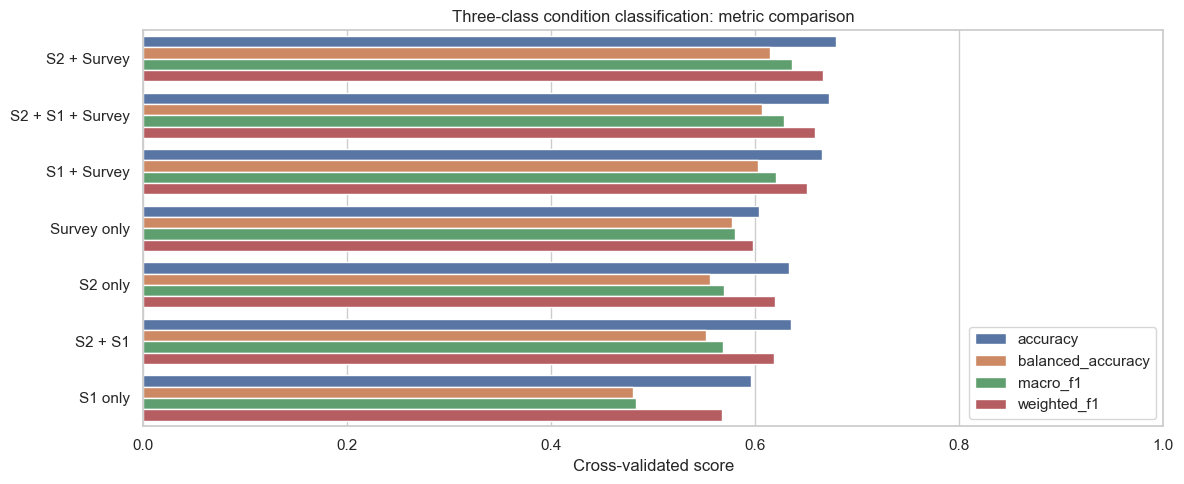

In [6]:
results_3, reports_3, cms_3 = run_suite(model_df, "target_3", TARGET_3_ORDER, FEATURE_SETS)
display(results_3)

metric_cols = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1"]
plot_df = results_3.melt(
    id_vars=["experiment"],
    value_vars=metric_cols,
    var_name="metric",
    value_name="score",
)
plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="score", y="experiment", hue="metric")
plt.xlim(0, 1)
plt.title("Three-class condition classification: metric comparison")
plt.xlabel("Cross-validated score")
plt.ylabel("")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Best three-class experiment by macro-F1: S2 + Survey


,precision,recall,f1-score,support
good,0.7357,0.5075,0.6006,735.0000
fair,0.6227,0.4771,0.5403,1484.0000
poor,0.6907,0.8596,0.7660,2351.0000
accuracy,0.6788,0.6788,0.6788,0.6788
macro avg,0.6830,0.6147,0.6356,4570.0000
weighted avg,0.6759,0.6788,0.6661,4570.0000


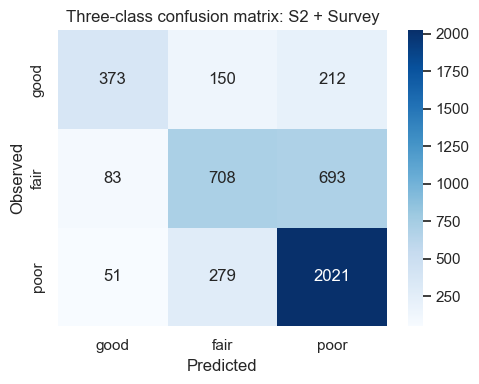

In [7]:
best_3 = results_3.iloc[0]["experiment"]
print(f"Best three-class experiment by macro-F1: {best_3}")
display(reports_3[best_3])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cms_3[best_3],
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=TARGET_3_ORDER,
    yticklabels=TARGET_3_ORDER,
)
plt.title(f"Three-class confusion matrix: {best_3}")
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.tight_layout()
plt.show()

## 6. Binary Good-vs-Poor Experiment

Here `Fair` is grouped with `Poor`, leaving a more operational binary classification: roads that are clearly good versus roads that are not good. This is especially useful for discussing prioritisation, because missing the `poor` class is a more serious operational error than over-predicting it.

,experiment,target,n_roads,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,good_precision,good_recall,good_f1,poor_precision,poor_recall,poor_f1
3,Survey only,target_binary,4570,21,0.8821,0.7400,0.7612,0.8764,0.6678,0.5306,0.5914,0.9134,0.9494,0.9311
5,S2 + Survey,target_binary,4570,88,0.8908,0.7040,0.7479,0.8766,0.7995,0.4286,0.5580,0.8994,0.9794,0.9377
4,S1 + Survey,target_binary,4570,58,0.8867,0.6977,0.7393,0.8722,0.7719,0.4190,0.5432,0.8976,0.9763,0.9353
6,S2 + S1 + Survey,target_binary,4570,125,0.8880,0.6891,0.7342,0.8713,0.8106,0.3959,0.5320,0.8946,0.9823,0.9364
1,S2 only,target_binary,4570,67,0.8586,0.6155,0.6448,0.8317,0.6540,0.2571,0.3691,0.8725,0.9739,0.9204
2,S2 + S1,target_binary,4570,104,0.8589,0.6080,0.6363,0.8293,0.6731,0.2381,0.3518,0.8701,0.9778,0.9208
0,S1 only,target_binary,4570,37,0.8381,0.5186,0.4988,0.7785,0.4667,0.0476,0.0864,0.8443,0.9896,0.9112


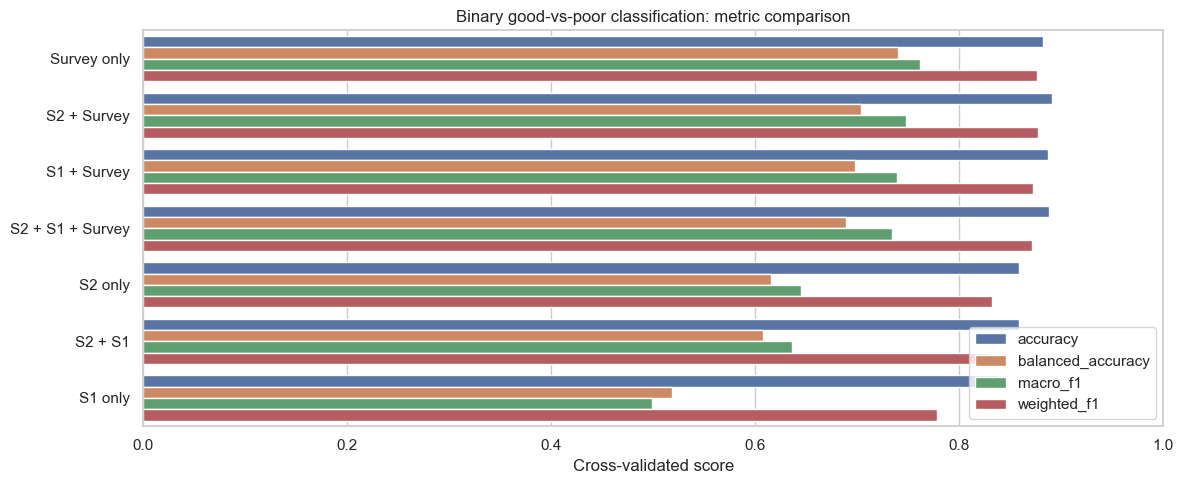

In [8]:
results_binary, reports_binary, cms_binary = run_suite(
    model_df,
    "target_binary",
    TARGET_BINARY_ORDER,
    FEATURE_SETS,
)
display(results_binary)

plot_df = results_binary.melt(
    id_vars=["experiment"],
    value_vars=metric_cols,
    var_name="metric",
    value_name="score",
)
plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="score", y="experiment", hue="metric")
plt.xlim(0, 1)
plt.title("Binary good-vs-poor classification: metric comparison")
plt.xlabel("Cross-validated score")
plt.ylabel("")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Best binary experiment by macro-F1: Survey only


,precision,recall,f1-score,support
good,0.6678,0.5306,0.5914,735.0000
poor,0.9134,0.9494,0.9311,3835.0000
accuracy,0.8821,0.8821,0.8821,0.8821
macro avg,0.7906,0.7400,0.7612,4570.0000
weighted avg,0.8739,0.8821,0.8764,4570.0000


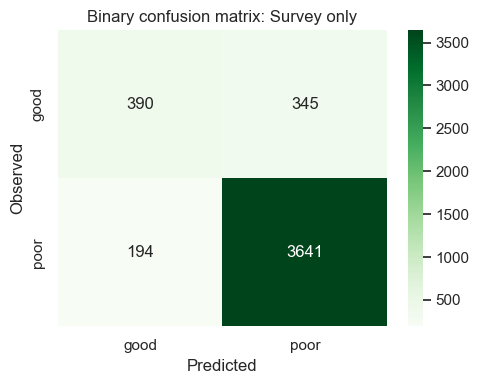

In [9]:
best_binary = results_binary.iloc[0]["experiment"]
print(f"Best binary experiment by macro-F1: {best_binary}")
display(reports_binary[best_binary])

plt.figure(figsize=(5, 4))
sns.heatmap(
    cms_binary[best_binary],
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=TARGET_BINARY_ORDER,
    yticklabels=TARGET_BINARY_ORDER,
)
plt.title(f"Binary confusion matrix: {best_binary}")
plt.xlabel("Predicted")
plt.ylabel("Observed")
plt.tight_layout()
plt.show()

## 7. Paved-Only Subset

This subset removes unpaved and gravel roads using the NIRTIMS pavement survey. It is stricter than the full-network experiment because the model cannot rely on obvious surface-material separation; it has to find condition signal within paved roads.

In [10]:
PAVED_TYPES = ["Asphalt", "Concrete", "SurfaceDressing"]
paved_df = model_df[model_df["pave_type"].isin(PAVED_TYPES)].copy()
print(f"Paved roads in modelling table: {len(paved_df):,}")
print(paved_df["pave_type"].value_counts())
print("\nThree-class target distribution:")
print(paved_df["target_3"].value_counts().reindex(TARGET_3_ORDER).fillna(0).astype(int))
print("\nBinary target distribution:")
print(paved_df["target_binary"].value_counts().reindex(TARGET_BINARY_ORDER).fillna(0).astype(int))

PAVED_FEATURE_SETS = {
    "S1 only": S1_FEAT_COLS,
    "S2 only": S2_FEAT_COLS,
    "S2 + S1": S2_FEAT_COLS + S1_FEAT_COLS,
}

paved_results_3, paved_reports_3, paved_cms_3 = run_suite(
    paved_df,
    "target_3",
    TARGET_3_ORDER,
    PAVED_FEATURE_SETS,
)
display(paved_results_3)

paved_results_binary, paved_reports_binary, paved_cms_binary = run_suite(
    paved_df,
    "target_binary",
    TARGET_BINARY_ORDER,
    PAVED_FEATURE_SETS,
)
display(paved_results_binary)

Paved roads in modelling table: 977
pave_type
Asphalt            791
SurfaceDressing    154
Concrete            32
Name: count, dtype: int64

Three-class target distribution:
target_3
good    473
fair    234
poor    270
Name: count, dtype: int64

Binary target distribution:
target_binary
good    473
poor    504
Name: count, dtype: int64


,experiment,target,n_roads,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,good_precision,good_recall,good_f1,fair_precision,fair_recall,fair_f1,poor_precision,poor_recall,poor_f1
2,S2 + S1,target_3,977,104,0.6203,0.5674,0.5623,0.6028,0.6753,0.7696,0.7194,0.4885,0.2735,0.3507,0.5798,0.6593,0.6170
1,S2 only,target_3,977,67,0.6039,0.5482,0.5443,0.5882,0.6772,0.7674,0.7195,0.4507,0.2735,0.3404,0.5452,0.6037,0.5729
0,S1 only,target_3,977,37,0.5517,0.4933,0.4923,0.5339,0.6000,0.7294,0.6584,0.3972,0.2393,0.2987,0.5287,0.5111,0.5198


,experiment,target,n_roads,n_features,accuracy,balanced_accuracy,macro_f1,weighted_f1,good_precision,good_recall,good_f1,poor_precision,poor_recall,poor_f1
2,S2 + S1,target_binary,977,104,0.7288,0.7270,0.7271,0.7278,0.7430,0.6723,0.7059,0.7177,0.7817,0.7483
1,S2 only,target_binary,977,67,0.7236,0.7226,0.7228,0.7233,0.7261,0.6892,0.7072,0.7216,0.7560,0.7384
0,S1 only,target_binary,977,37,0.6407,0.6394,0.6394,0.6401,0.6374,0.5983,0.6172,0.6435,0.6806,0.6615


## 8. SAR Feature Diagnostics

These charts are not final proof of causality, but they help explain whether S1 features are separating classes in a physically interpretable way. If distributions overlap heavily, it supports the argument that GRD backscatter alone is a weak proxy and that coherence, incidence-angle normalisation, or better ground truth would be needed for a stronger condition model.

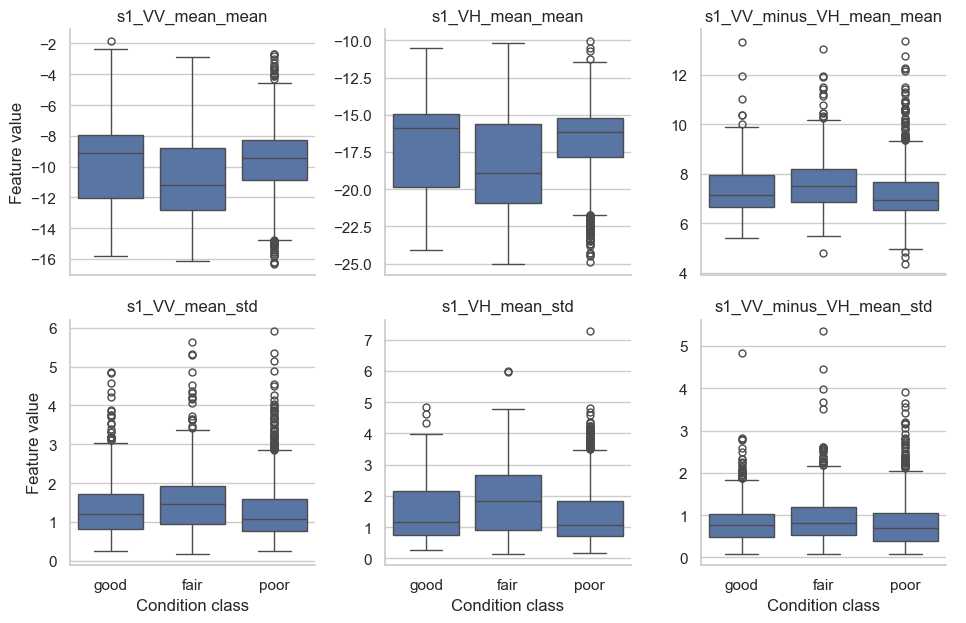

In [11]:
s1_diag_cols = [
    c for c in [
        "s1_VV_mean_mean",
        "s1_VH_mean_mean",
        "s1_VV_minus_VH_mean_mean",
        "s1_VV_mean_std",
        "s1_VH_mean_std",
        "s1_VV_minus_VH_mean_std",
    ]
    if c in model_df.columns
]

diag = model_df[["target_3"] + s1_diag_cols].melt(
    id_vars="target_3",
    var_name="feature",
    value_name="value",
)
g = sns.catplot(
    data=diag,
    x="target_3",
    y="value",
    col="feature",
    kind="box",
    col_wrap=3,
    sharey=False,
    order=TARGET_3_ORDER,
    height=3.2,
)
g.set_titles("{col_name}")
g.set_axis_labels("Condition class", "Feature value")
plt.tight_layout()
plt.show()

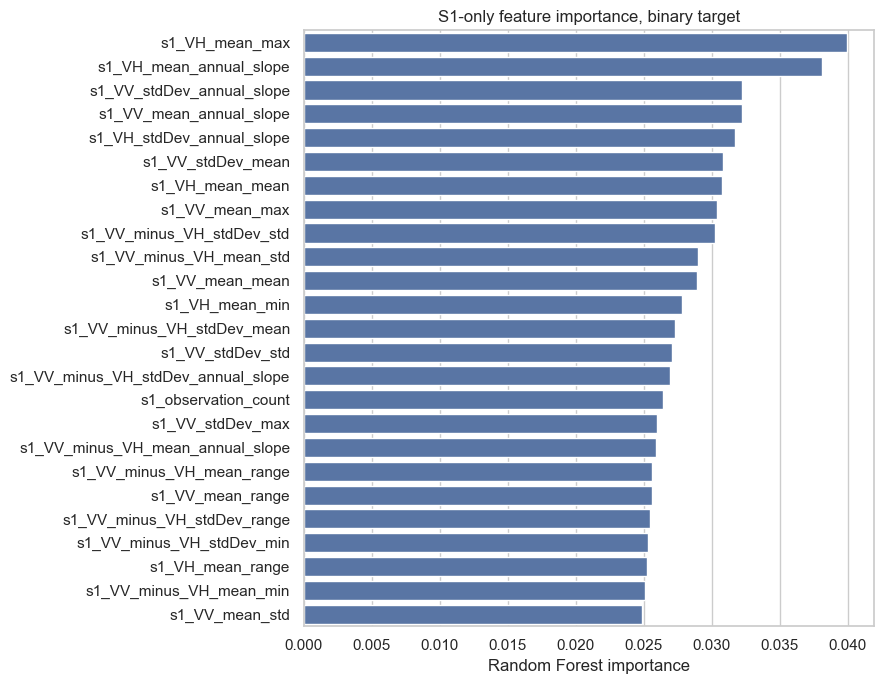

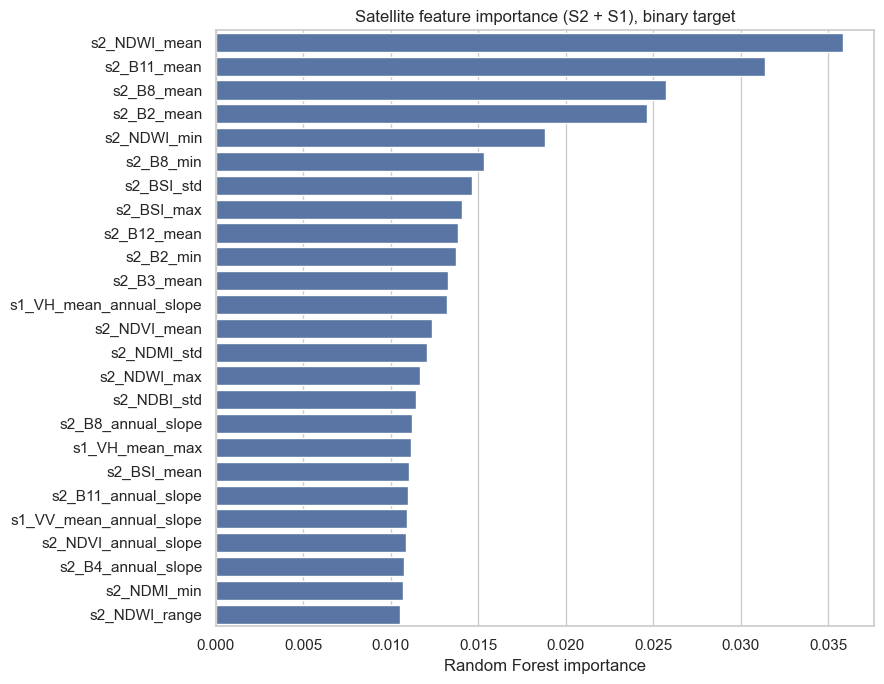

In [12]:
def fit_feature_importance(df, feature_cols, target_col, title, top_n=25):
    usable = df.dropna(subset=[target_col]).copy()
    X = usable[feature_cols]
    y = usable[target_col]
    model = make_rf()
    model.fit(X, y)
    rf = model.named_steps["rf"]
    importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

    top = importances.head(top_n).reset_index()
    top.columns = ["feature", "importance"]
    plt.figure(figsize=(9, 7))
    sns.barplot(data=top, x="importance", y="feature")
    plt.title(title)
    plt.xlabel("Random Forest importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
    return importances


importance_s1 = fit_feature_importance(
    model_df,
    S1_FEAT_COLS,
    "target_binary",
    "S1-only feature importance, binary target",
)

importance_combined = fit_feature_importance(
    model_df,
    S2_FEAT_COLS + S1_FEAT_COLS,
    "target_binary",
    "Satellite feature importance (S2 + S1), binary target",
)

## 9. Interpretation Prompts for Dissertation Write-Up

Use the executed results to write the section, rather than assuming SAR helps:

- If `S1 only` is below `S2 only`, describe S1 GRD backscatter as weaker than optical indices for this dataset.
- If `S2 + S1` improves macro-F1 or poor-class recall, frame SAR as complementary rather than replacing Sentinel-2.
- If `Survey only` or `Satellite + Survey` dominates, state that field-derived engineering attributes still carry stronger condition signal than satellite summaries.
- If binary performance is much better than three-class performance, use this to justify a practical prioritisation model while acknowledging that fine-grained condition grading remains data limited.
- If the paved-only subset performs poorly, discuss pavement-type confounding in the full-network model.